# Day 02：Q、K、V 的三角舞 —— 注意力的数学核心> 🚀 第十一周 · 注意力时代 · 第 2 天昨天我们认识了注意力的直觉：翻译时"回头看"。今天，我们要深入注意力的数学核心——**Q、K、V 的三角舞**。**今天的任务**：1. 理解 Q、K、V 的生成方式2. 手写一个完整的注意力计算3. 理解缩放点积注意力（Scaled Dot-Product Attention）---

## 1. 历史剧场：2015 年 Bahdanau 注意力2015 年，Dzmitry Bahdanau 等人在论文《Neural Machine Translation by Jointly Learning to Align and Translate》中首次将注意力机制引入 Seq2Seq 模型。核心思想：Decoder 在生成每个词时，不再只依赖一个固定的上下文向量，而是计算源序列每个位置的注意力权重，动态地提取信息。这篇论文彻底改变了机器翻译——注意力让翻译质量不再随句子长度下降。---

## 2. 生活隐喻：图书馆找书想象你在图书馆找书：- **Q（查询）**：你告诉图书管理员"我想找关于深度学习的书"- **K（键）**：每本书的标签/摘要——"这本是讲 CNN 的"、"这本是讲 RNN 的"- **V（值）**：书的实际内容过程：1. 你的 Q 和每本书的 K 比较（匹配）2. 越匹配的书，权重越高3. 最终拿到的结果是所有书的 V 的加权混合---

<p align="center">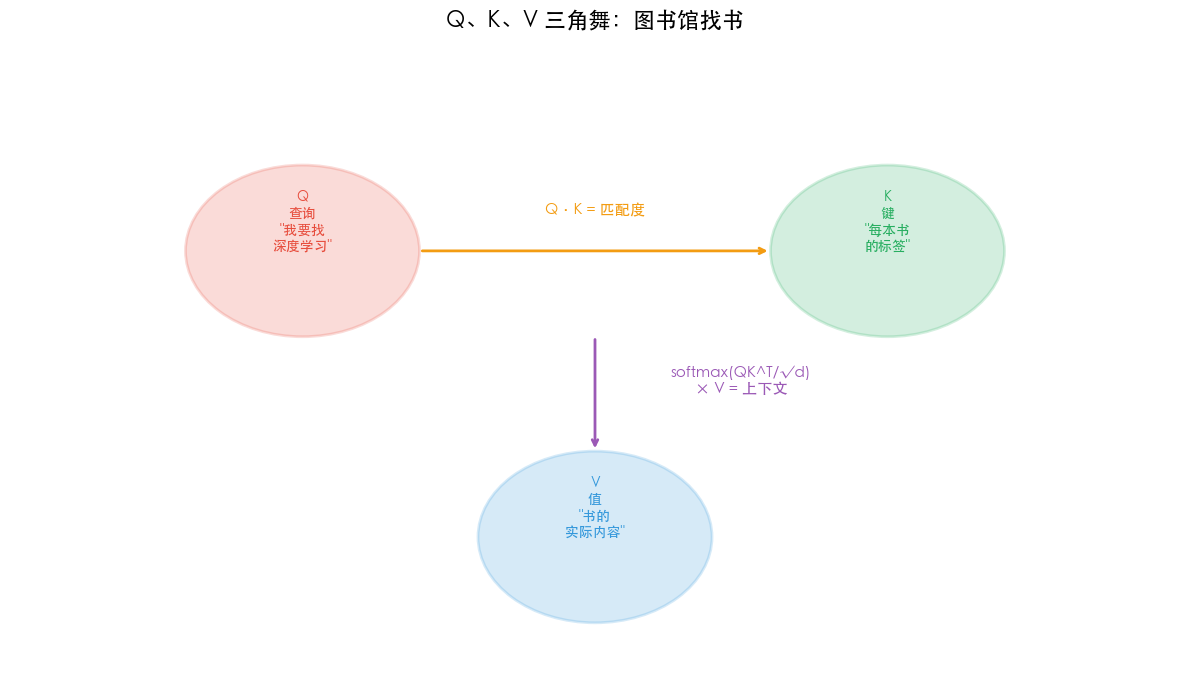</p>*QKV 三角舞示意图*

## 3. 数学直觉：缩放点积注意力### 3.1 生成 Q、K、V给定输入 $X$（形状：序列长度 × 模型维度），通过三个线性变换生成 Q、K、V：$$Q = X W_Q, \quad K = X W_K, \quad V = X W_V$$其中 $W_Q, W_K, W_V$ 是可学习的权重矩阵。### 3.2 计算注意力$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$拆开来看：1. $QK^T$：计算 Q 和 K 的点积（相似度矩阵）2. $\div \sqrt{d_k}$：缩放（防止点积过大导致 softmax 饱和）3. $\text{softmax}$：归一化为概率分布4. $\times V$：加权求和**为什么要除以 $\sqrt{d_k}$？**当 $d_k$ 很大时，点积的方差也很大，softmax 输出会接近 one-hot（某个位置接近 1，其他接近 0），梯度几乎为零。除以 $\sqrt{d_k}$ 可以稳定梯度。---

## 4. 代码实验室：手写缩放点积注意力

In [ ]:
import torchimport torch.nn as nnimport torch.nn.functional as Fimport matplotlib.pyplot as pltimport numpy as npplt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei']plt.rcParams['axes.unicode_minus'] = False

### 4.1 手写注意力层

In [ ]:
class ScaledDotProductAttention:    def __init__(self, d_model, d_k, d_v):        self.d_k = d_k        self.W_q = np.random.randn(d_model, d_k) * np.sqrt(2.0 / d_model)        self.W_k = np.random.randn(d_model, d_k) * np.sqrt(2.0 / d_model)        self.W_v = np.random.randn(d_model, d_v) * np.sqrt(2.0 / d_model)    def forward(self, X):        Q = X @ self.W_q        K = X @ self.W_k        V = X @ self.W_v        scores = Q @ K.T / np.sqrt(self.d_k)        exp_scores = np.exp(scores - scores.max(axis=-1, keepdims=True))        attn_weights = exp_scores / exp_scores.sum(axis=-1, keepdims=True)        context = attn_weights @ V        return context, attn_weights, Q, K, Vnp.random.seed(42)d_model = 8d_k = 6d_v = 6seq_len = 5X = np.random.randn(seq_len, d_model)attention = ScaledDotProductAttention(d_model, d_k, d_v)context, weights, Q, K, V = attention.forward(X)print(f"输入 X: {X.shape}")print(f"查询 Q: {Q.shape}")print(f"键   K: {K.shape}")print(f"值   V: {V.shape}")print(f"注意力权重: {weights.shape}")print(f"上下文输出: {context.shape}")

### 4.2 可视化 Q、K、V

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))labels = ['词1', '词2', '词3', '词4', '词5']for ax, mat, title in zip(    [axes[0,0], axes[0,1], axes[0,2]],    [Q, K, V],    ['Query (Q) — "我要找什么"', 'Key (K) — "每个位置有什么"', 'Value (V) — "每个位置的内容"']):    im = ax.imshow(mat, aspect='auto', cmap='RdBu_r')    ax.set_ylabel('序列位置', fontsize=11)    ax.set_xlabel('维度', fontsize=11)    ax.set_title(title, fontsize=12)    ax.set_yticks(range(seq_len))    ax.set_yticklabels(labels)    plt.colorbar(im, ax=ax)im = axes[1,0].imshow(weights, aspect='auto', cmap='YlOrRd', vmin=0)axes[1,0].set_ylabel('Query 位置', fontsize=11)axes[1,0].set_xlabel('Key 位置', fontsize=11)axes[1,0].set_title('注意力权重 (softmax 后)', fontsize=12)axes[1,0].set_xticks(range(seq_len))axes[1,0].set_xticklabels(labels)axes[1,0].set_yticks(range(seq_len))axes[1,0].set_yticklabels(labels)plt.colorbar(im, ax=axes[1,0])im = axes[1,1].imshow(context, aspect='auto', cmap='RdBu_r')axes[1,1].set_ylabel('序列位置', fontsize=11)axes[1,1].set_xlabel('维度', fontsize=11)axes[1,1].set_title('上下文输出 (加权 V)', fontsize=12)axes[1,1].set_yticks(range(seq_len))axes[1,1].set_yticklabels(labels)plt.colorbar(im, ax=axes[1,1])row_sums = weights.sum(axis=1)axes[1,2].bar(range(seq_len), row_sums, color='#3498db', alpha=0.8)axes[1,2].set_xlabel('Query 位置', fontsize=11)axes[1,2].set_ylabel('权重之和', fontsize=11)axes[1,2].set_title('每行权重之和 (应=1)', fontsize=12)axes[1,2].set_xticks(range(seq_len))axes[1,2].set_xticklabels(labels)axes[1,2].grid(True, alpha=0.3)plt.suptitle('Q、K、V 的三角舞：注意力机制全流程', fontsize=16, y=1.02)plt.tight_layout()plt.show()

### 4.3 缩放的效果

In [ ]:
print("缩放的效果：为什么需要除以 sqrt(d_k)？\n")for dk in [4, 16, 64, 256]:    np.random.seed(42)    q = np.random.randn(dk)    k = np.random.randn(dk)    dot = q @ k    scaled = dot / np.sqrt(dk)    print(f"d_k={dk:3d}: 点积={dot:8.2f}, 缩放后={scaled:8.2f}, "          f"方差比={dk/dk:.1f}")print()print("结论: d_k 越大，点积的绝对值越大")print("      不缩放的话，softmax 会饱和，梯度接近零")

---

## 今日结语今天我们手写了缩放点积注意力：$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right) V$$Q 是"我要找什么"，K 是"每个位置有什么"，V 是"每个位置的内容"。三者通过点积和 softmax 产生注意力权重，最终加权求和得到上下文。缩放因子 $\sqrt{d_k}$ 是防止 softmax 饱和的关键。明天，我们将学习"多头注意力"——让模型同时关注不同类型的关系。---### 翻译词典| 生活中的直觉 | 深度学习术语 ||---|---|| 图书馆找书 | Q 查询 K，提取 V || "我要找关于深度学习的书" | Query——查询向量 || 每本书的标签/摘要 | Key——键向量 || 书的实际内容 | Value——值向量 || 越匹配权重越高 | softmax(QK^T/√d_k) || 防止极端偏好 | 缩放因子 √d_k——稳定 softmax |